Carrier frequency: 3.90 GHz
1λ = 0.08 m (7.69 cm)
0.5λ = 0.04 m (3.85 cm)
0.25λ = 0.02 m (1.92 cm)
2λ = 0.15 m (15.38 cm)
10λ = 0.77 m (76.92 cm)

=== Tx Array = 1x1
=== 2T (1x1)SA (1x1)
a_real shape: (1, 2, 1, 2, 2)
Total Receiver: 1
Total Receiver Antenna (Polarization Count): 2
Total Transmitter: 1
Total Transmitter Antenna (Polarization Count): 2
Total paths found: 2


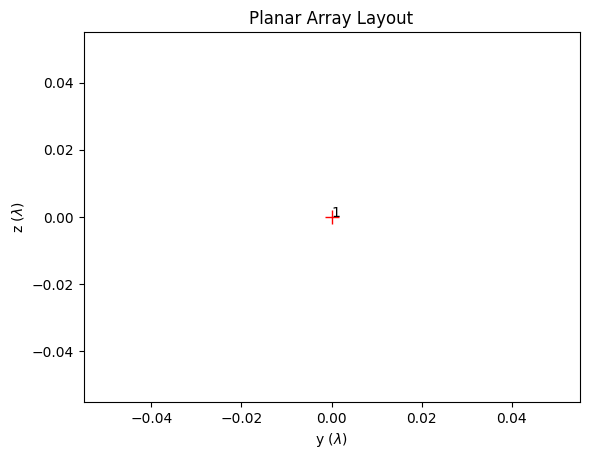

<Figure size 400x400 with 0 Axes>

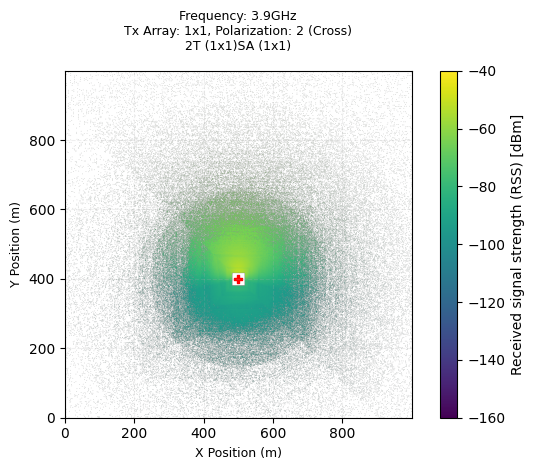


=== Tx Array = 2x1
=== 4T (1x1)SA (2x1)
a_real shape: (1, 2, 1, 4, 2)
Total Receiver: 1
Total Receiver Antenna (Polarization Count): 2
Total Transmitter: 1
Total Transmitter Antenna (Polarization Count): 4
Total paths found: 2


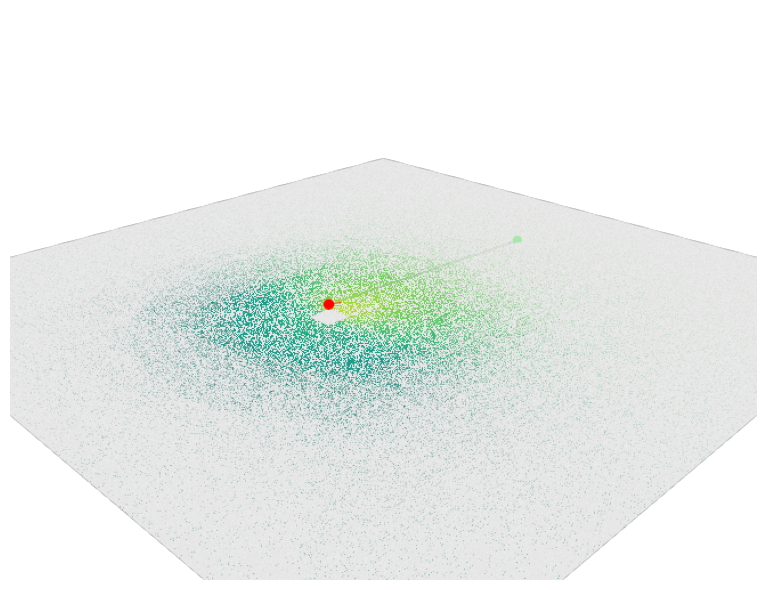

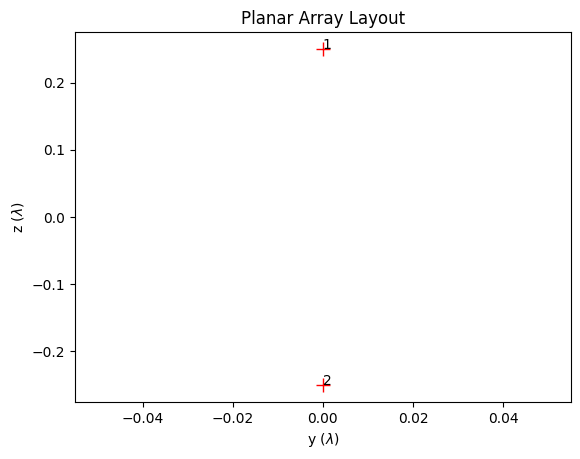

<Figure size 400x400 with 0 Axes>

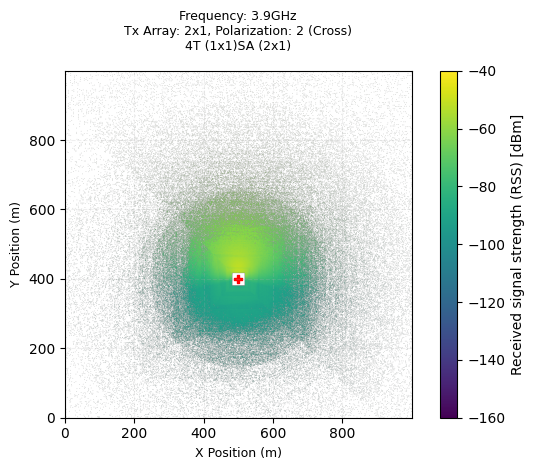


=== Tx Array = 2x2
=== 8T (1x1)SA (2x2)
a_real shape: (1, 2, 1, 8, 2)
Total Receiver: 1
Total Receiver Antenna (Polarization Count): 2
Total Transmitter: 1
Total Transmitter Antenna (Polarization Count): 8
Total paths found: 2


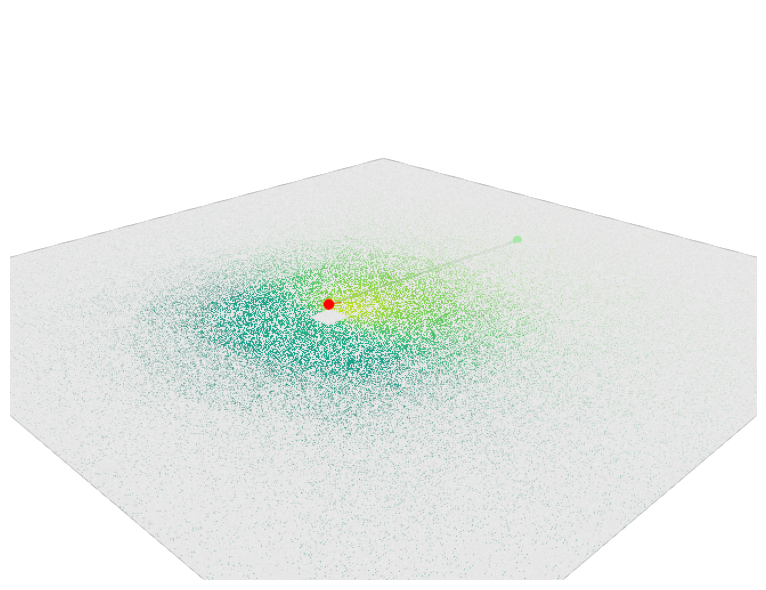

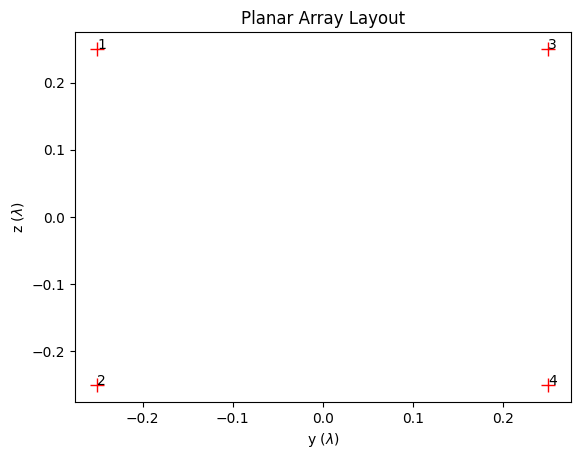

<Figure size 400x400 with 0 Axes>

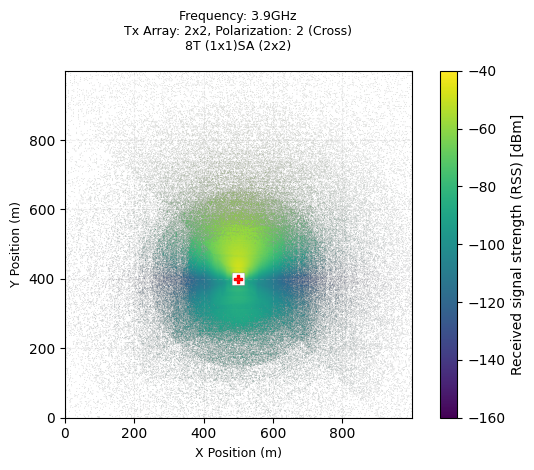


=== Tx Array = 4x2
=== 16T (1x1)SA (4x2)
a_real shape: (1, 2, 1, 16, 2)
Total Receiver: 1
Total Receiver Antenna (Polarization Count): 2
Total Transmitter: 1
Total Transmitter Antenna (Polarization Count): 16
Total paths found: 2


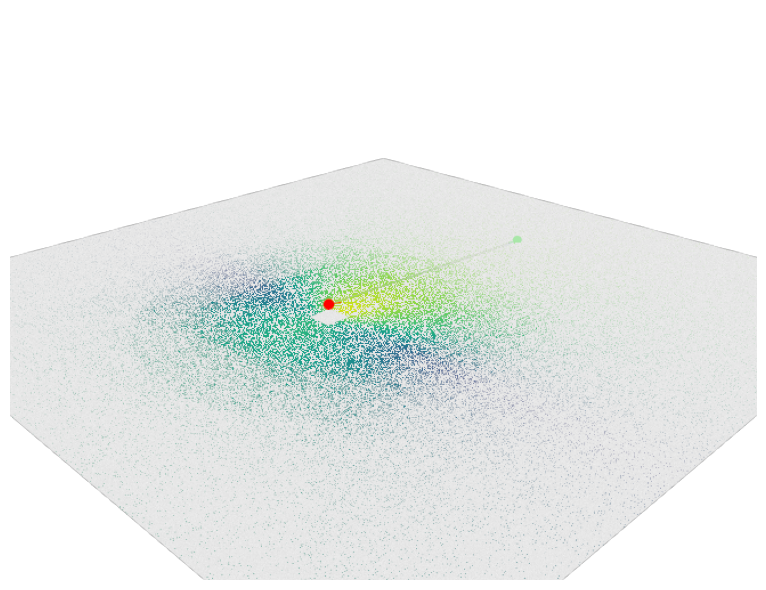

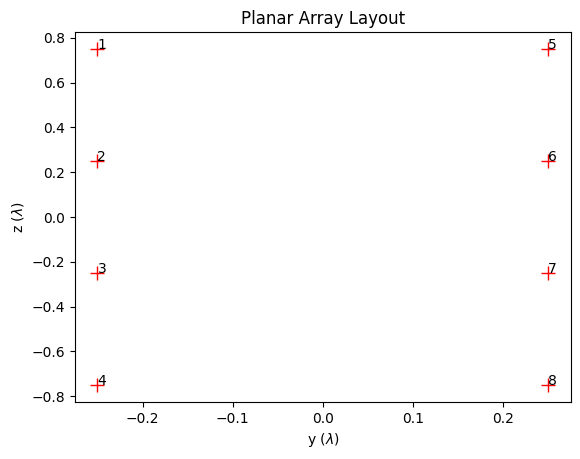

<Figure size 400x400 with 0 Axes>

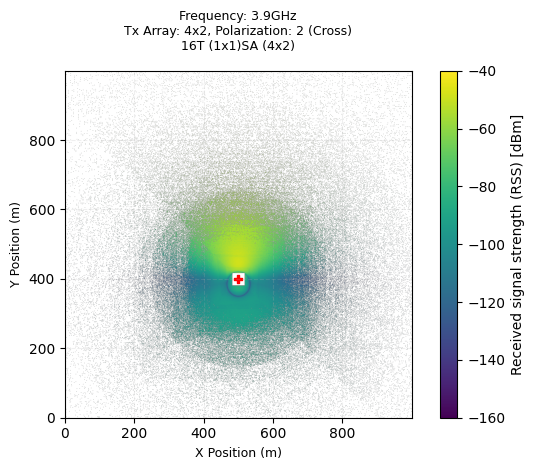


=== Tx Array = 4x4
=== 32T (1x1)SA (4x4)
a_real shape: (1, 2, 1, 32, 2)
Total Receiver: 1
Total Receiver Antenna (Polarization Count): 2
Total Transmitter: 1
Total Transmitter Antenna (Polarization Count): 32
Total paths found: 2


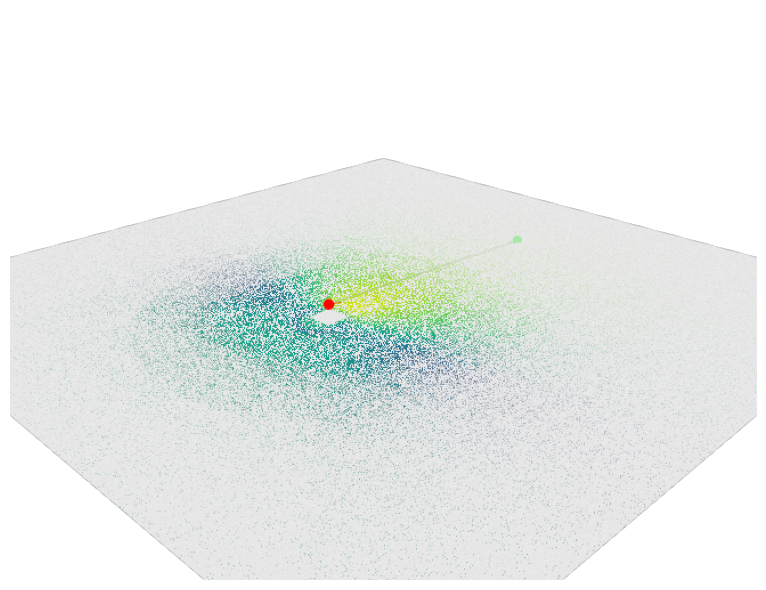

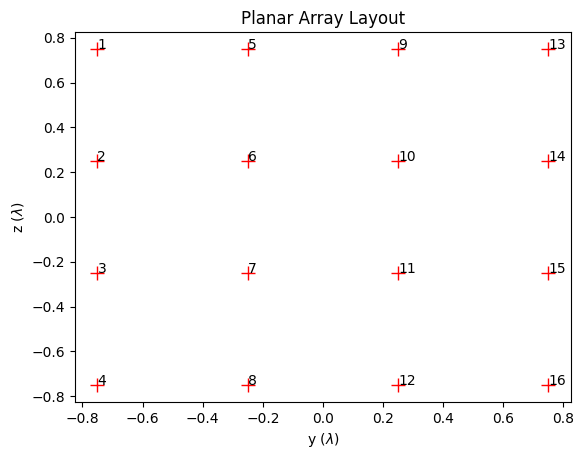

<Figure size 400x400 with 0 Axes>

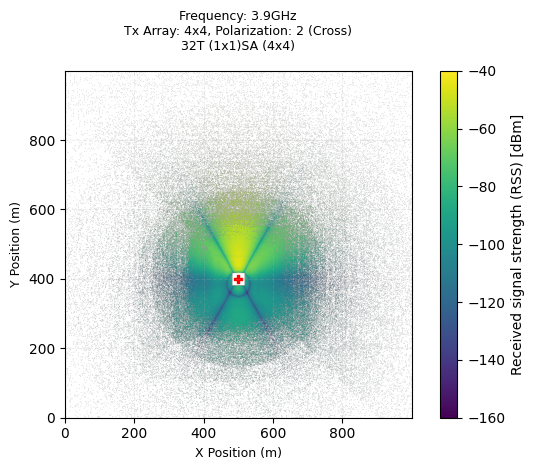


=== Tx Array = 8x4
=== 64T (1x1)SA (8x4)
a_real shape: (1, 2, 1, 64, 2)
Total Receiver: 1
Total Receiver Antenna (Polarization Count): 2
Total Transmitter: 1
Total Transmitter Antenna (Polarization Count): 64
Total paths found: 2


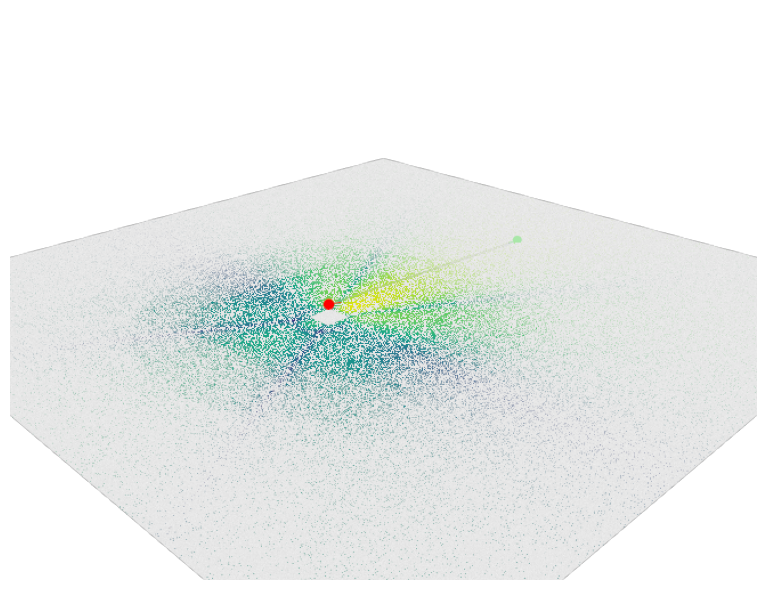

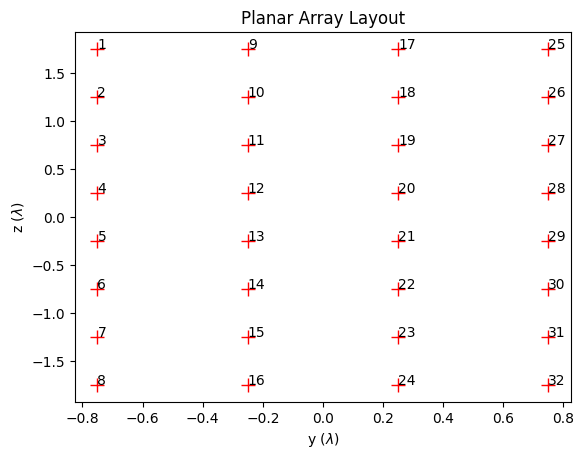

<Figure size 400x400 with 0 Axes>

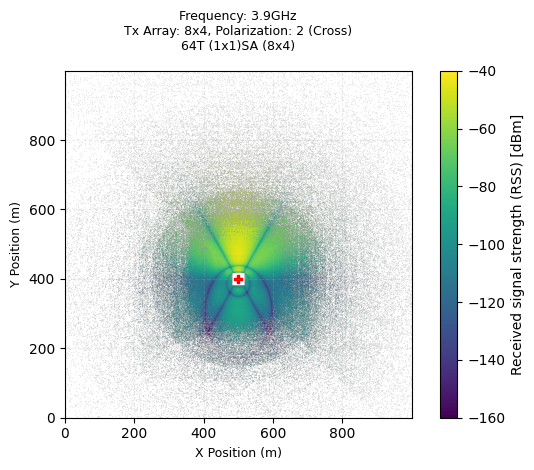


=== Tx Array = 8x8
=== 128T (1x1)SA (8x8)
a_real shape: (1, 2, 1, 128, 2)
Total Receiver: 1
Total Receiver Antenna (Polarization Count): 2
Total Transmitter: 1
Total Transmitter Antenna (Polarization Count): 128
Total paths found: 2


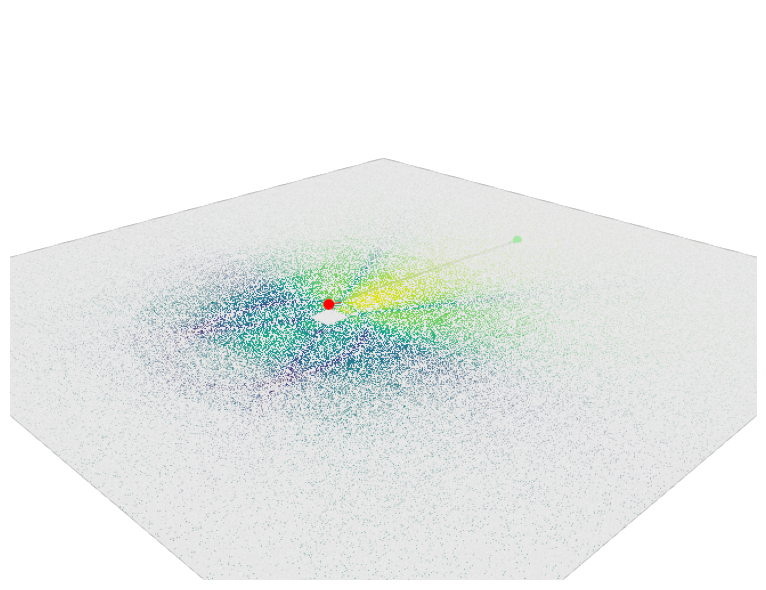

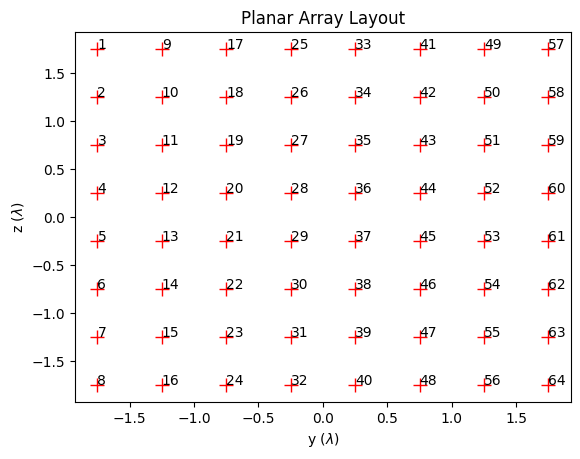

<Figure size 400x400 with 0 Axes>

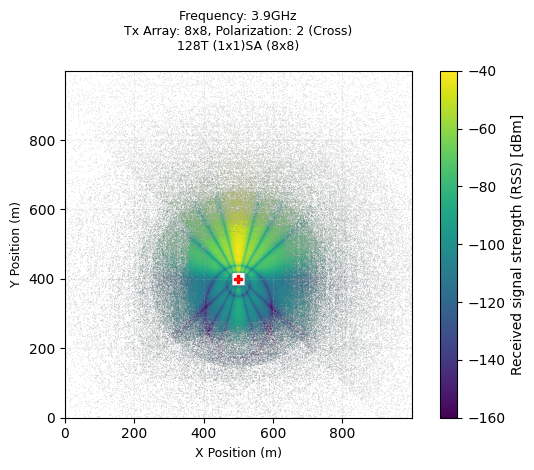


Tx Array Results:

   tx_rows  tx_cols tx_array           mimo_type  rss_non_coherent  num_rx  \
0        1        1      1x1    2T (1x1)SA (1x1)        -65.156219       1   
1        2        1      2x1    4T (1x1)SA (2x1)        -62.145920       1   
2        2        2      2x2    8T (1x1)SA (2x2)        -59.135620       1   
3        4        2      4x2   16T (1x1)SA (4x2)        -56.125320       1   
4        4        4      4x4   32T (1x1)SA (4x4)        -53.115021       1   
5        8        4      8x4   64T (1x1)SA (8x4)        -50.104721       1   
6        8        8      8x8  128T (1x1)SA (8x8)        -47.094421       1   

   num_rx_ant  num_tx  num_tx_ant  num_paths  
0           2       1           2          2  
1           2       1           4          2  
2           2       1           8          2  
3           2       1          16          2  
4           2       1          32          2  
5           2       1          64          2  
6           2       1     

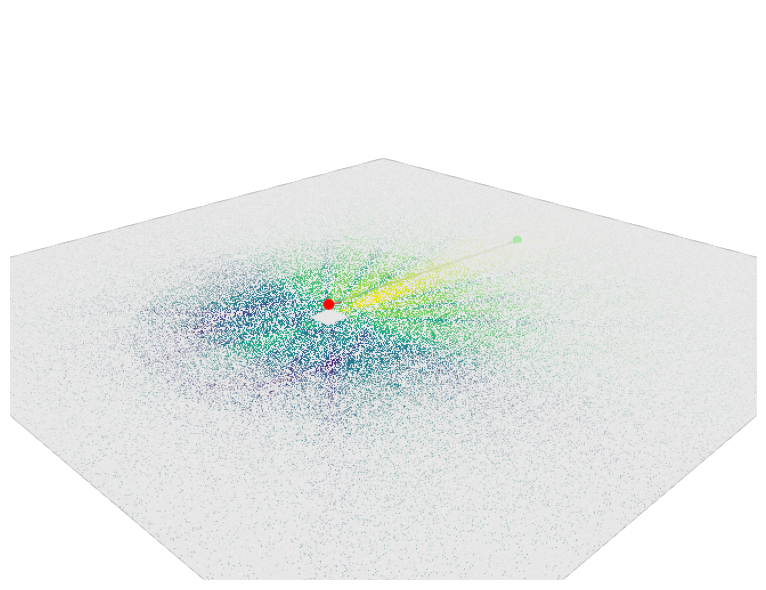

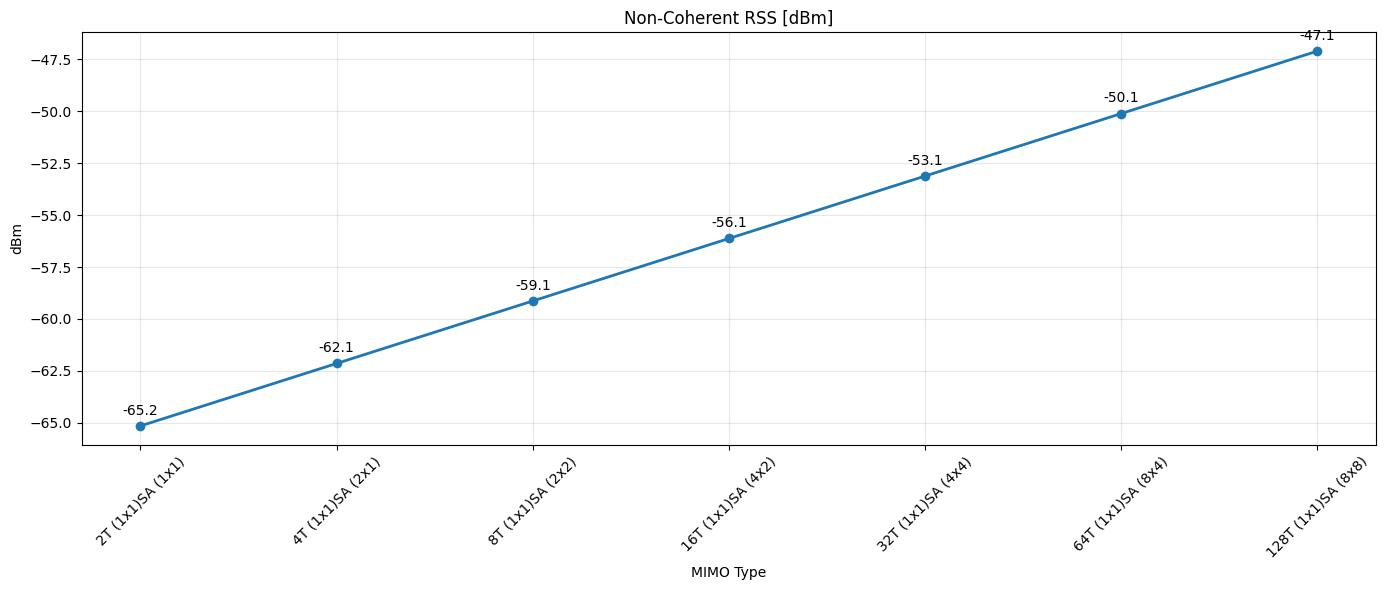

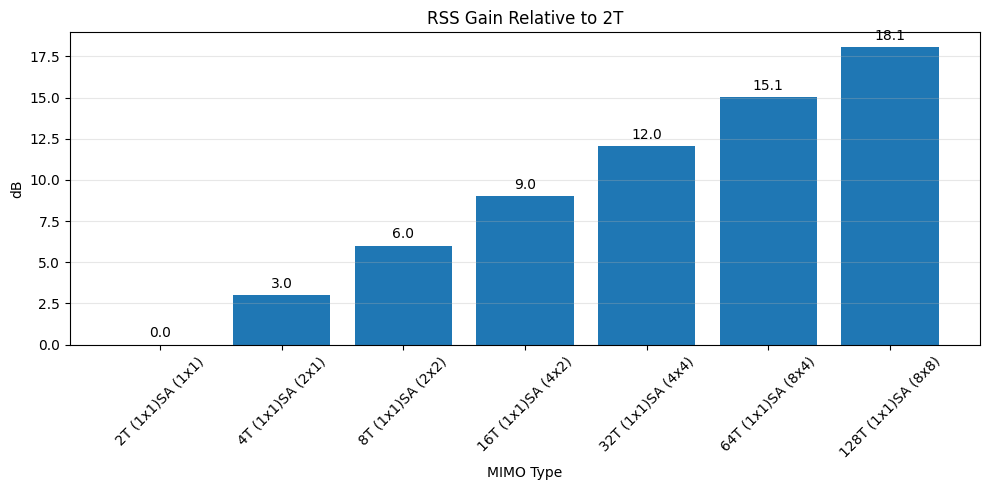

In [1]:
# Import libraries
import numpy as np
from sionna.rt import load_scene, ITURadioMaterial, Transmitter, Receiver, PlanarArray, RadioMapSolver, PathSolver, Camera
import matplotlib.pyplot as plt
import pandas as pd
import os

# Import scene from blender mitsuba export (.xml)
scene = load_scene("blender-assets/1km-field.xml")

# Add frequency to scene
carrier_freq = 3.9e9 # In Hz
scene.frequency = carrier_freq

# Print frequency and lamda
c = 3e8
lam = c / carrier_freq
print(f"Carrier frequency: {carrier_freq/1e9:.2f} GHz")
print(f"1λ = {lam:.2f} m ({lam*100:.2f} cm)")
print(f"0.5λ = {lam/2:.2f} m ({lam/2*100:.2f} cm)")
print(f"0.25λ = {lam/4:.2f} m ({lam/4*100:.2f} cm)")
print(f"2λ = {lam*2:.2f} m ({lam*2*100:.2f} cm)")
print(f"10λ = {lam*10:.2f} m ({lam*10*100:.2f} cm)")

# Deploy Tx and Rx location

# Helper function to sync transmitter 0 degree with scene 0 degree
def compass_orientation(azimuth_deg, tilt_deg, roll_deg=0):

    # Sionna by default implement 0 degree Tx at X+ axis, -90 to achieve 0 degree at Y+ axis (North)
    sionna_azimuth = (90 - azimuth_deg) % 360

    # return radian
    return [
        float(np.deg2rad(sionna_azimuth)),
        float(np.deg2rad(tilt_deg)),
        float(np.deg2rad(roll_deg))
    ]

# Deploy Tx
tx_azimuth_deg = 0
tx_tilt_deg = 10

tx = Transmitter(
    "tx",
    position = [0, -100, 18], # x, y, z (location and height, in meter)
    orientation=compass_orientation(azimuth_deg=tx_azimuth_deg,tilt_deg=tx_tilt_deg), 
    power_dbm=18
)

tx_power_dbm = tx.power_dbm[0]

# Deploy Rx
rx_azimuth_deg = 0
rx_tilt_deg = 0

rx = Receiver(
    "rx",
    [0, 300, 1.5],
    orientation=[
        float(np.deg2rad(rx_azimuth_deg)), float(np.deg2rad(rx_tilt_deg)), 0.0]
)

# Point Rx to face Tx direction
rx.look_at(tx.position)

# Add Tx and Rx to the scene
scene.add(tx)
scene.add(rx)

# Loop different array size
tx_array_sizes = [
    (1,1),     # 1
    (2,1),     # 2
    (2,2),     # 4
    (4,2),     # 8
    (4,4),     # 16
    (8,4),     # 32
    (8,8)      # 64
]

results = []

p_solver = PathSolver()

for num_rows, num_cols in tx_array_sizes:

    print(f"\n=== Tx Array = {num_rows}x{num_cols}\n=== {num_rows*num_cols*2}T (1x1)SA ({num_rows}x{num_cols})")

    # Update Tx array
    scene.tx_array = PlanarArray(
        num_rows=num_rows,
        num_cols=num_cols,
        vertical_spacing=0.5,
        horizontal_spacing=0.5,
        pattern="tr38901",
        polarization="cross"
    )

    scene.tx_array.show()

    # Update Rx array
    scene.rx_array = PlanarArray(
        num_rows=1,
        num_cols=1,
        vertical_spacing=0.5,
        horizontal_spacing=0.5,
        pattern="iso",
        polarization="cross"
    )

    # Run path solver
    p_solver = PathSolver()

    paths = p_solver(
        scene,
        max_depth=10,
        samples_per_src=10**6
    )

    # Extract path coefficients (a function return 2 components: a_real, a_imag)
    a_real, a_imag = paths.a
    print("a_real shape:", a_real.shape)

    a_real = a_real.numpy()
    a_imag = a_imag.numpy()

    # Reconstruct complex channel coefficients in real and imaginary form
    a = a_real + 1j * a_imag

    # Extract a coefficient
    num_rx = a.shape[0]
    num_rx_ant = a.shape[1]
    num_tx = a.shape[2]
    num_tx_ant = a.shape[3]
    num_paths = a.shape[-1]
    print(f"Total Receiver: {num_rx}")
    print(f"Total Receiver Antenna (Polarization Count): {num_rx_ant}")
    print(f"Total Transmitter: {num_tx}")
    print(f"Total Transmitter Antenna (Polarization Count): {num_tx_ant}")
    print(f"Total paths found: {num_paths}")

    # Non-coherent RSS
    rss_non_coherent = (
        tx_power_dbm
        + 10*np.log10(
            max(np.sum(np.abs(a)**2), 1e-30)
        )
    )

    # # Coherent RSS
    # rss_coherent = (
    #     tx_power_dbm
    #     + 10*np.log10(
    #         max(np.abs(np.sum(a))**2, 1e-30)
    #     )
    # )

    results.append({
        "tx_rows": num_rows,
        "tx_cols": num_cols,
        "tx_array": f"{num_rows}x{num_cols}",
        "mimo_type": f"{num_rows*num_cols*2}T (1x1)SA ({num_rows}x{num_cols})",
        "rss_non_coherent": rss_non_coherent,
        "num_rx": num_rx,
        "num_rx_ant": num_rx_ant,
        "num_tx": num_tx,
        "num_tx_ant": num_tx_ant,
        "num_paths": num_paths
    })

    # Plot 2D Radio Map
    rm_solver = RadioMapSolver()

    rm = rm_solver(
        scene,
        max_depth=10,
        samples_per_tx=10**7,
        cell_size=(1, 1),
        center=[0, 0, 0],
        size=[1000, 1000],
        orientation=[0, 0, 0]
    )

    plt.figure(figsize=(4, 4))
    rm.show(metric="rss")
    plt.title(
        f"Frequency: {carrier_freq/1e9}GHz\nTx Array: {num_rows}x{num_cols}, Polarization: 2 (Cross)\n{num_rows*num_cols*2}T (1x1)SA ({num_rows}x{num_cols})",
        fontsize=9,
        pad=15
    )
    plt.xlabel("X Position (m)", fontsize=9)
    plt.ylabel("Y Position (m)", fontsize=9)
    plt.clim(-160, -40)
    plt.grid(
        alpha=0.2,
        linestyle="--"
    )
    plt.tight_layout()
    plt.show()

    # Plot 3D Radio Map + Paths
    rm_solver = RadioMapSolver()

    rm = rm_solver(
            scene,
            max_depth=10, # Number of maximum iteration allowed per paths
            samples_per_tx=10**7, # Number of rays launch in transmitter
            cell_size=(1, 1),
            center=[0, 0, 0],
            size=[1000, 1000], # Size of area to simulate (meter)
            orientation=[0, 0, 0]
        )

    p_solver = PathSolver()

    paths = p_solver(
        scene,
        max_depth=10,
        samples_per_src=10**7
    )

    cam = Camera(
    position=(800, -800, 500),
    look_at=(0, 0, 0)
    )

    scene.render(
        
        paths=paths,
        radio_map=rm,
        
        camera=cam,

        rm_metric="rss",
        rm_db_scale=True,

        rm_vmax = -40,
        rm_vmin = -160,

        show_devices=True,
        show_orientations=True
    )

# Results dataframe
df_results = pd.DataFrame(results)
print("\nTx Array Results:\n")
print(df_results)

df_results.to_csv(
    "output/export_rss_txarraysize.csv",
    index=False
)

# Plot Non-Coherent RSS
plt.figure(figsize=(14, 6))

plt.plot(
    df_results["mimo_type"],
    df_results["rss_non_coherent"],
    marker="o",
    linewidth=2
)

# Data labels
for x, y in zip(
    df_results["mimo_type"],
    df_results["rss_non_coherent"]
):
    plt.annotate(
        f"{y:.1f}",
        (x, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center"
    )

plt.title("Non-Coherent RSS [dBm]")
plt.xlabel("MIMO Type")
plt.ylabel("dBm")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# RSS Gain Chart
rss_reference = df_results.loc[
    df_results["tx_array"] == "1x1",
    "rss_non_coherent"
].iloc[0]

df_results["rss_gain_db"] = (
    df_results["rss_non_coherent"]
    - rss_reference
)

plt.figure(figsize=(10,5))

bars = plt.bar(
    df_results["mimo_type"],
    df_results["rss_gain_db"]
)

plt.bar_label(
    bars,
    fmt="%.1f",
    padding=3
)

plt.title("RSS Gain Relative to 2T")
plt.xlabel("MIMO Type")
plt.ylabel("dB")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Optional - Scene Preview (Radio Map)
rm_solver = RadioMapSolver()

rm = rm_solver(
        scene,
        max_depth=10, # Number of maximum objects iteration allowed per paths
        samples_per_tx=10**7, # Number of rays launch in transmitter
        cell_size=(1, 1), # Simulation plane mesh size (meter)
        center=[0, 0, 0],
        size=[1000, 1000], # Size of area to simulate (meter)
        orientation=[0, 0, 0]
    )

# Optional - Scene Preview (Paths)
p_solver = PathSolver()

paths = p_solver(
    scene,
    max_depth=10,
    samples_per_src=10**7
)

scene.preview(
    paths=paths,
    radio_map=rm,

    rm_metric="rss",
    rm_db_scale=True,

    rm_vmax = -40,
    rm_vmin = -160,

    show_devices=True,
    show_orientations=True,

    point_picker=False
)